## Examples: Multiple Linear regression - fitting a model in sklearn

#### In this notebook, we delve into the intricacies of multiple linear regression, building upon the foundational understanding of simple linear regression. We explore how to fit a model using sklearn, taking into account multiple predictor variables to predict a response variable. Additionally, we introduce the mtcars dataset, a classic dataset in statistics, to illustrate the concepts in a practical context

### Learning Objectives
#### By the end of this video, you should be able to:
##### - Understand the principles of multiple linear regression and its extension from simple linear regression
##### - Load and preprocess data for multiple linear regression analysis
##### - Fit a multiple linear regression model using sklearn
##### - Interpret the coefficients of the fitted model to understand their influence on the response variable
##### - Evaluate model accuracy using mean squared error (MSE) and root mean squared error (RMSE)

In [1]:
%matplotlib notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# read the dataset
df = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/regression_sprint/mtcars.csv', index_col=0)

In [3]:
# Explore the shape of the dataset
df.shape

(32, 11)

### Modelling miles per gallon

In [4]:
df.columns

Index(['mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear',
       'carb'],
      dtype='object')

<IPython.core.display.Javascript object>


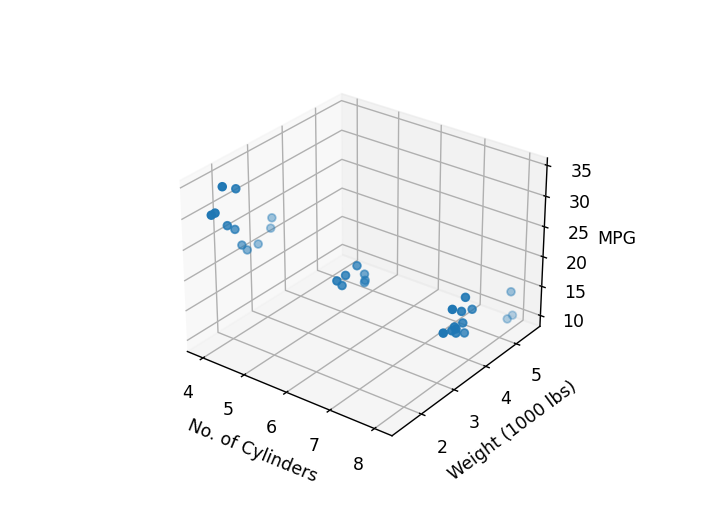

In [5]:
# create figure and 3D axes
fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection='3d')

# set axis labels
ax.set_zlabel('MPG')
ax.set_xlabel('No. of Cylinders')
ax.set_ylabel('Weight (1000 lbs)')

# Scatter plot with response variable and 2 predictors
ax.scatter(df['cyl'], df['wt'], df['mpg'])

### Fitting a multivariate regression model

In [6]:
# import regression module
from sklearn.linear_model import LinearRegression

# Split predictors and response
X = df.drop(['mpg'], axis=1)
y = df['mpg']

In [7]:
X

,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
model,,,,,,,,,,
Mazda RX4,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,8,360.0,175,3.15,3.440,17.02,0,0,3,2
Valiant,6,225.0,105,2.76,3.460,20.22,1,0,3,1
Duster 360,8,360.0,245,3.21,3.570,15.84,0,0,3,4
Merc 240D,4,146.7,62,3.69,3.190,20.00,1,0,4,2
Merc 230,4,140.8,95,3.92,3.150,22.90,1,0,4,2


In [8]:
# Create model object
lm = LinearRegression()

In [9]:
# Import train/test split module
from sklearn.model_selection import train_test_split

In [10]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1
)

In [11]:
# Train model
lm.fit(X_train, y_train)

LinearRegression()

In [12]:
# Extract the model intercept
beta_0 = float(lm.intercept_)

In [13]:
# Extract model coefficients
beta_js = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])

In [14]:
print("Intercept:", beta_0)

Intercept: 8.465282572242584


In [15]:
beta_js

,Coefficient
cyl,0.190203
disp,0.008613
hp,-0.022868
drat,1.477014
wt,-3.564785
qsec,0.924358
vs,-1.248904
am,1.340890
gear,0.482458
carb,-0.187354


<IPython.core.display.Javascript object>


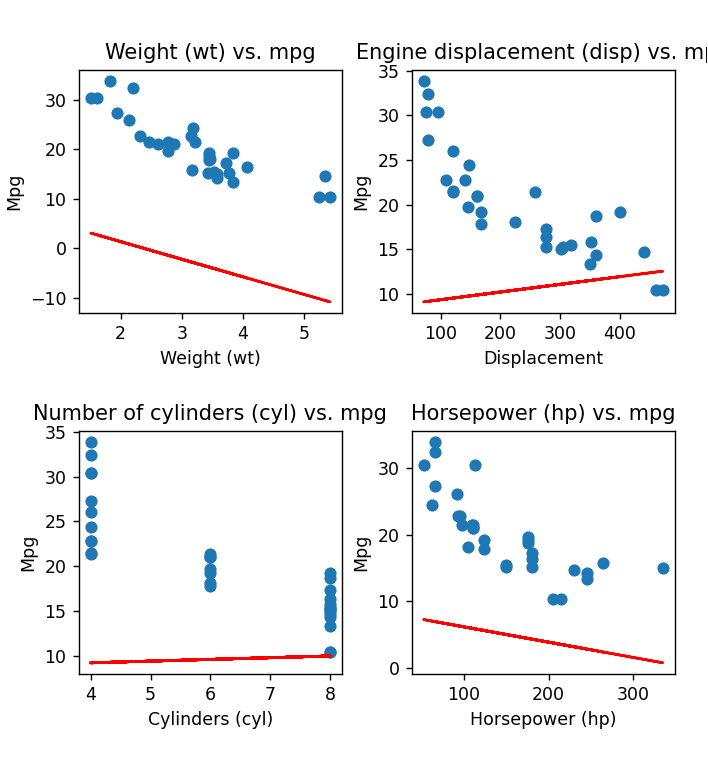

In [20]:
fig, axs = plt.subplots(2, 2, figsize=(9,7))

axs[0,0].scatter(df['wt'], df['mpg'])
axs[0,0].plot(df['wt'], lm.intercept_ + lm.coef_[4]*df['wt'], color='red')
axs[0,0].title.set_text('Weight (wt) vs. mpg')
axs[0,0].set_xlabel('Weight (wt)')
axs[0,0].set_ylabel('Mpg')

axs[0,1].scatter(df['disp'], df['mpg'])
axs[0,1].plot(df['disp'], lm.intercept_ + lm.coef_[1]*df['disp'], color='red')
axs[0,1].title.set_text('Engine displacement (disp) vs. mpg')
axs[0,1].set_xlabel('Displacement')
axs[0,1].set_ylabel('Mpg')

axs[1,0].scatter(df['cyl'], df['mpg'])
axs[1,0].plot(df['cyl'], lm.intercept_ + lm.coef_[0]*df['cyl'], color='red')
axs[1,0].title.set_text('Number of cylinders (cyl) vs. mpg')
axs[1,0].set_xlabel('Cylinders (cyl)')
axs[1,0].set_ylabel('Mpg')

axs[1,1].scatter(df['hp'], df['mpg'])
axs[1,1].plot(df['hp'], lm.intercept_ + lm.coef_[2]*df['hp'], color='red')
axs[1,1].title.set_text('Horsepower (hp) vs. mpg')
axs[1,1].set_xlabel('Horsepower (hp)')
axs[1,1].set_ylabel('Mpg')

fig.tight_layout(pad=3.0)
plt.show()

### Assessing model accuracy

In [21]:
# Comparison linear model
slr = LinearRegression()

slr.fit(X_train[['disp']], y_train)

LinearRegression()

In [22]:
from sklearn import metrics
import math

In [23]:
# dictionary of results
results_dict = {
    'Training MSE': {
        "SLR": metrics.mean_squared_error(y_train, slr.predict(X_train[['disp']])),
        "MLR": metrics.mean_squared_error(y_train, lm.predict(X_train))
    },
    'Test MSE': {
        "SLR": metrics.mean_squared_error(y_test, slr.predict(X_test[['disp']])),
        "MLR": metrics.mean_squared_error(y_test, lm.predict(X_test))
    },
    'Test RMSE': {
        "SLR": math.sqrt(metrics.mean_squared_error(y_test, slr.predict(X_test[['disp']]))),
        "MLR": math.sqrt(metrics.mean_squared_error(y_test, lm.predict(X_test)))
    }
}

In [24]:
# Create Dataframe from dictionary
results_df = pd.DataFrame(data=results_dict)

In [25]:
results_df

,Training MSE,Test MSE,Test RMSE
SLR,8.201521,20.500165,4.527711
MLR,3.737534,11.520901,3.394245
